2026-07-31 10:31:50,496 [INFO] Bắt đầu tính toán Technical Indicators & Macro Features...


Kích thước dữ liệu gốc: (2192, 5)


2026-07-31 10:31:52,858 [INFO] Hoàn tất. Tổng số features (bao gồm vĩ mô): 21
2026-07-31 10:31:52,860 [INFO] Đã loại bỏ 69 dòng NaN ở đầu chuỗi dữ liệu.


Kích thước dữ liệu sau khi thêm Features: (2123, 21)


,RSI_14,Stoch_k,ROC,BBU_20_2.0,BBL_20_2.0,ATR,OBV,CMF,DXY,SP500
Date,,,,,,,,,,
2025-12-27,77.545039,95.959596,12.082671,69392.389869,59347.610131,1803.303887,1.637643e+08,0.399574,98.019997,6929.939941
2025-12-28,77.545039,95.959596,12.082671,70305.448926,58944.551074,1881.639324,1.637643e+08,0.352839,98.019997,6929.939941
2025-12-29,84.744285,97.744361,17.343750,72453.403605,57906.596395,2118.665087,1.659759e+08,0.474408,98.040001,6905.740234
2025-12-30,83.490939,93.750000,17.031250,74112.655081,57387.344919,2103.046152,1.642115e+08,0.472519,98.239998,6896.240234
2025-12-31,69.628432,73.643411,13.125000,74948.248963,57531.751037,2195.685712,1.623387e+08,0.352046,98.279999,6845.500000


Đã lưu bộ dữ liệu Feature tại: ../data/processed/GAS_features.parquet


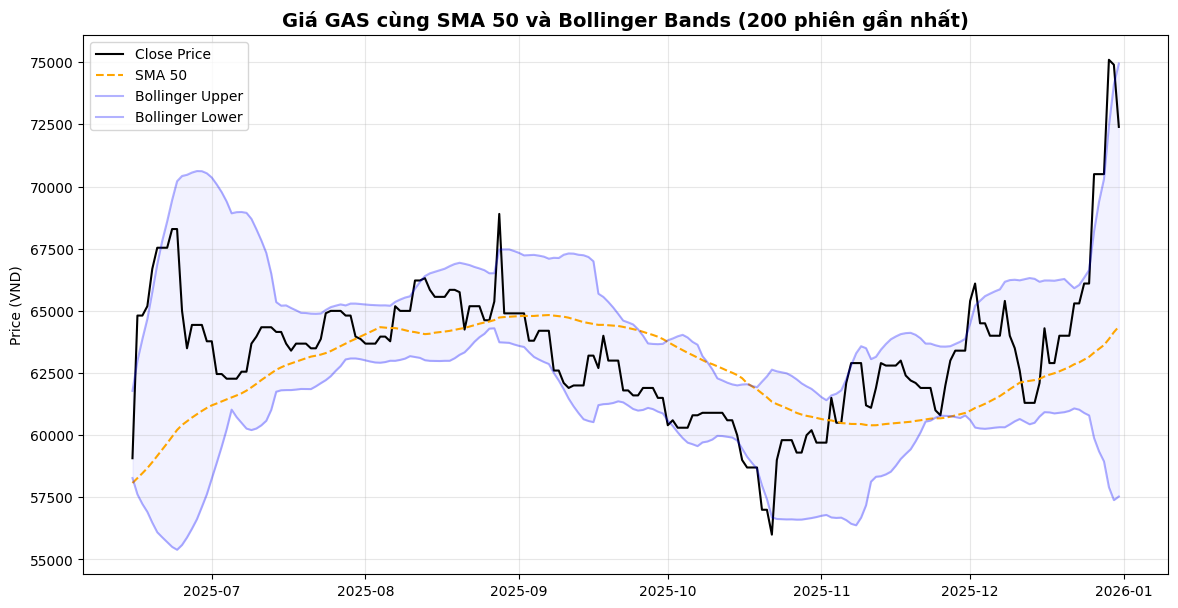

In [1]:
# Cell 1: Import
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from utils.feature_engineer import TechnicalFeatures

# Tự động reload lại code nếu sửa file .py
%load_ext autoreload
%autoreload 2

# Cell 2: Đọc dữ liệu
df_clean = pd.read_parquet("../data/processed/GAS_cleaned.parquet")
print("Kích thước dữ liệu gốc:", df_clean.shape)

# Cell 3: Sinh Feature Đặc trưng
te = TechnicalFeatures(df_clean)
df_features = te.generate_all_features()

print(f"Kích thước dữ liệu sau khi thêm Features: {df_features.shape}")
# Hiển thị 5 dòng, 10 cột cuối
display(df_features.iloc[-5:, -10:])

# Cell 4: Lưu dữ liệu để huấn luyện ML
output_path = "../data/processed/GAS_features.parquet"
df_features.to_parquet(output_path)
print(f"Đã lưu bộ dữ liệu Feature tại: {output_path}")

# Cell 5: Trực quan hóa kiểm tra (Close, SMA50 và Bollinger Bands)
plt.figure(figsize=(14, 7))

# Lấy 200 ngày gần nhất để biểu đồ không bị quá dày đặc
plot_df = df_features.tail(200)

plt.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black', linewidth=1.5)
plt.plot(plot_df.index, plot_df['SMA_50'], label='SMA 50', color='orange', linestyle='--')
plt.plot(plot_df.index, plot_df['BBU_20_2.0'], label='Bollinger Upper', color='blue', alpha=0.3)
plt.plot(plot_df.index, plot_df['BBL_20_2.0'], label='Bollinger Lower', color='blue', alpha=0.3)
plt.fill_between(plot_df.index, plot_df['BBL_20_2.0'], plot_df['BBU_20_2.0'], color='blue', alpha=0.05)

plt.title("Giá GAS cùng SMA 50 và Bollinger Bands (200 phiên gần nhất)", fontsize=14, fontweight="bold")
plt.ylabel("Price (VND)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()